In [1]:
!hdfs dfs -D dfs.replication=1 -cp -f data/*.jsonl hdfs://nn:9000/
!hdfs dfs -D dfs.replication=1 -cp -f data/*.csv hdfs://nn:9000/

In [2]:
from pyspark.sql import SparkSession
spark = (SparkSession.builder.appName("cs544")
         .master("spark://boss:7077")
         .config("spark.executor.memory", "1G")
         .config("spark.sql.warehouse.dir", "hdfs://nn:9000/user/hive/warehouse")
         .enableHiveSupport()
         .getOrCreate())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 23:16:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
problems_df = spark.read.json("hdfs://nn:9000/problems.jsonl")
problems_df.write.mode("overwrite").saveAsTable("problems")

26/04/08 23:16:32 WARN ObjectStore: Version information not found in metastore. hive.metastore.schema.verification is not enabled so recording the schema version 2.3.0
26/04/08 23:16:32 WARN ObjectStore: setMetaStoreSchemaVersion called but recording version is disabled: version = 2.3.0, comment = Set by MetaStore UNKNOWN@172.18.0.5
26/04/08 23:16:35 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
26/04/08 23:16:35 WARN HiveConf: HiveConf of name hive.internal.ss.authz.settings.applied.marker does not exist


In [4]:
problems_df.limit(5).show()

+-------------+--------+---------+---------+---------------+----------+---------------+-------------------------+------------------+--------------------+-------------+----------+------------+------+----------+
|cf_contest_id|cf_index|cf_points|cf_rating|        cf_tags|difficulty|generated_tests|is_description_translated|memory_limit_bytes|                name|private_tests|problem_id|public_tests|source|time_limit|
+-------------+--------+---------+---------+---------------+----------+---------------+-------------------------+------------------+--------------------+-------------+----------+------------+------+----------+
|          322|       A|    500.0|     1000|            [0]|         7|             93|                    false|         256000000|322_A. Ciel and D...|           45|         1|           2|     2|         1|
|          760|       D|   1000.0|     1600|         [1, 2]|        10|             51|                    false|         256000000|  760_D. Travel Card|       

In [5]:
solutions_df = spark.read.json("hdfs://nn:9000/solutions.jsonl")
solutions_df.write \
    .mode("overwrite") \
    .bucketBy(4, "language") \
    .saveAsTable("solutions")

In [6]:
solutions_df.limit(5).show()

+----------+--------+----------+--------------------+
|is_correct|language|problem_id|            solution|
+----------+--------+----------+--------------------+
|      true| PYTHON2|         1|n,m = [int(nm) fo...|
|      true| PYTHON2|         1|mn = map(int, raw...|
|      true| PYTHON2|         1|n,m=map(int, raw_...|
|      true|    JAVA|         1|import java.io.Bu...|
|      true|    JAVA|         1|import java.util....|
+----------+--------+----------+--------------------+



In [7]:
languages_df = spark.read.csv("hdfs://nn:9000/languages.csv", header=True, inferSchema=True)
problem_tests_df = spark.read.csv("hdfs://nn:9000/problem_tests.csv", header=True, inferSchema=True)
sources_df = spark.read.csv("hdfs://nn:9000/sources.csv", header=True, inferSchema=True)
tags_df = spark.read.csv("hdfs://nn:9000/tags.csv", header=True, inferSchema=True)

languages_df.createOrReplaceTempView("languages")
problem_tests_df.createOrReplaceTempView("problem_tests")
sources_df.createOrReplaceTempView("sources")
tags_df.createOrReplaceTempView("tags")

Q1: How many problems are there with a cf_rating of at least 1600, having private_tests, and a name containing "_A." (Case Sensitive)? Answer using all three Spark APIs.

In [8]:
#Q1
rdd_count = problems_df.rdd.filter(
    lambda x: x["cf_rating"] is not None
    and x["cf_rating"] >= 1600
    and "_A." in x["name"]
    and x["private_tests"] > 0
).count()

df_filtered = problems_df.filter(
    (problems_df.cf_rating >= 1600) &
    (problems_df.name.contains("_A.")) &
    (problems_df.private_tests > 0)
)
dataframe_count = df_filtered.count()

problems_df.createOrReplaceTempView("problems_tmp")
sql_count = spark.sql("""
SELECT COUNT(*) as cnt
FROM problems_tmp
WHERE cf_rating >= 1600
  AND name LIKE '%_A.%'
  AND private_tests > 0
""").collect()[0]["cnt"]

(rdd_count, dataframe_count, sql_count)

(217, 217, 217)

Q2: How many correct PYTHON3 solutions are from CODEFORCES?

In [9]:
#Q2
q2 = spark.sql("""
SELECT COUNT(*)
FROM solutions s
JOIN problems p ON s.problem_id = p.problem_id
JOIN sources src ON p.source = src.source
WHERE s.is_correct = true
  AND s.language = 'PYTHON3'
  AND src.source_name = 'CODEFORCES'
""")
q2.collect()[0][0]

10576

Q3: How many problems are of easy/medium/hard difficulty?

In [10]:
#Q3
q3 = spark.sql("""
SELECT
  SUM(CASE WHEN difficulty <= 5 THEN 1 ELSE 0 END) AS Easy,
  SUM(CASE WHEN difficulty > 5 AND difficulty <= 10 THEN 1 ELSE 0 END) AS Medium,
  SUM(CASE WHEN difficulty > 10 THEN 1 ELSE 0 END) AS Hard
FROM problems
""").collect()[0]

{
    'Easy': q3['Easy'],
    'Medium': q3['Medium'],
    'Hard': q3['Hard']
}

{'Easy': 409, 'Medium': 5768, 'Hard': 2396}

Q4: What tables/views are in our warehouse?

In [11]:
#Q4
{
    'problems': False,
    'solutions': False,
    'languages': True,
    'problem_tests': True,
    'sources': True,
    'tags': True
}

{'problems': False,
 'solutions': False,
 'languages': True,
 'problem_tests': True,
 'sources': True,
 'tags': True}

Q5: Does the query plan for a GROUP BY on solutions data need to shuffle/exchange rows if the data is pre-bucketed?

In [12]:
#Q5
spark.sql("""
EXPLAIN
SELECT language, COUNT(*)
FROM solutions
GROUP BY language
""").show(truncate=False)
# Exchange does not occur in the output

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|plan                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

Q6: Does caching make it faster to compute averages over a subset of a bigger dataset?

In [13]:
#Q6
import time

filtered_df = problem_tests_df.filter(problem_tests_df.is_generated == False)

def compute_avg(df):
    return df.selectExpr(
        "avg(input_chars)",
        "avg(output_chars)"
    ).collect()

times = []

# 1st run (no cache)
start = time.time()
compute_avg(filtered_df)
times.append(time.time() - start)

# cache
filtered_df.cache()

# 2nd run (after cache, but not materialized yet)
start = time.time()
compute_avg(filtered_df)
times.append(time.time() - start)

# 3rd run (cached data reused)
start = time.time()
compute_avg(filtered_df)
times.append(time.time() - start)

# uncache
filtered_df.unpersist()

times

[0.8155562877655029, 0.8912749290466309, 0.1800539493560791]

Part 3: Spark and Generative AI

In [14]:
import os
from google import genai

client = genai.Client(
    vertexai=True,
    project=os.environ['GOOGLE_CLOUD_PROJECT'],
    location='us-central1',
)

schema = """
Tables:

problems(problem_id, name, cf_rating, difficulty, time_limit, memory_limit_bytes, source)
solutions(problem_id, language, is_correct)
sources(source, source_name)
languages(...)
problem_tests(...)
tags(...)
"""

def human_query(english_question):
    prompt = f"""
        You are a Spark SQL generator.
        
        Given a question, output ONLY a valid Spark SQL query.
        Do NOT include explanations.
        Do NOT include markdown.
        Return ONLY the SQL query.
        
        Schema:
        {schema}
        
        Question:
        {english_question}
        """

    response = client.models.generate_content(
        model='gemini-2.5-pro',
        contents=prompt,
        config={'temperature': 0}
    )

    query = response.text.strip()

    result = spark.sql(query).collect()[0][0]

    return int(result)

Q7: How many JAVA solutions are there?

In [15]:
#Q7
human_query("How many JAVA solutions are there?")

28722

Q8: What is the maximum memory limit in bytes?

In [16]:
#Q8
human_query("What is the maximum memory limit in bytes?")

1024000000

Q9: Do the problems with a missing cf_rating appear more or less challenging than other problems?

In [17]:
#Q9
codeforces_problems = problems_df.join(sources_df, problems_df.source == sources_df.source)\
                                 .filter(sources_df.source_name == 'CODEFORCES')

train_df = codeforces_problems.filter((codeforces_problems.cf_rating > 0) & (codeforces_problems.problem_id % 2 == 0))

test_df = codeforces_problems.filter((codeforces_problems.cf_rating > 0) & (codeforces_problems.problem_id % 2 == 1))

missing_df = codeforces_problems.filter(codeforces_problems.cf_rating == 0)

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml import Pipeline

feature_cols = ['difficulty', 'time_limit', 'memory_limit_bytes']

assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

dt = DecisionTreeRegressor(featuresCol='features', labelCol='cf_rating', maxDepth=5)

pipeline = Pipeline(stages=[assembler, dt])

model = pipeline.fit(train_df)

predictions_missing = model.transform(missing_df)

train_avg = train_df.agg({'cf_rating': 'avg'}).collect()[0][0]
test_avg = test_df.agg({'cf_rating': 'avg'}).collect()[0][0]
missing_avg_pred = predictions_missing.agg({'prediction': 'avg'}).collect()[0][0]

q9_result = (train_avg, test_avg, missing_avg_pred)
q9_result

(1887.9377431906614, 1893.1106471816283, 1950.4728638818783)

Q10: How does tree depth impact the quality of predictions?

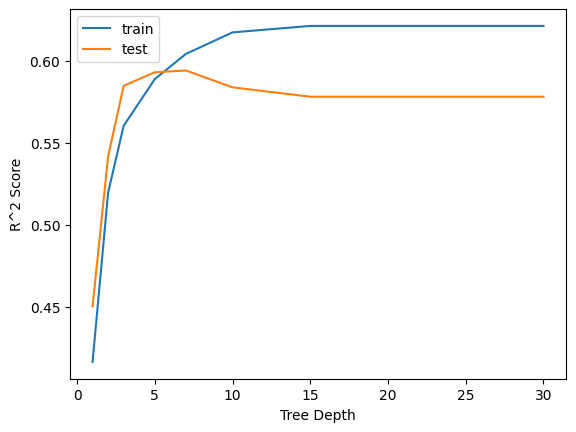

{"depth":{"0":1,"1":2,"2":3,"3":5,"4":7,"5":10,"6":15,"7":20,"8":25,"9":30},"train":{"0":0.4165232341,"1":0.5196985669,"2":0.5604188787,"3":0.5888249718,"4":0.6041716987,"5":0.6172907631,"6":0.6212285845,"7":0.6212285845,"8":0.6212285845,"9":0.6212285845},"test":{"0":0.4503904026,"1":0.5418856179,"2":0.5847461912,"3":0.5929835263,"4":0.5940872453,"5":0.5838230167,"6":0.5780981739,"7":0.5780981739,"8":0.5780981739,"9":0.5780981739}}


In [18]:
#Q10
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import RegressionEvaluator

depths = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
results = []

evaluator = RegressionEvaluator(labelCol="cf_rating", predictionCol="prediction", metricName="r2")

for depth in depths:
    dt = DecisionTreeRegressor(featuresCol='features', labelCol='cf_rating', maxDepth=depth)
    pipeline = Pipeline(stages=[assembler, dt])
    model = pipeline.fit(train_df)
    
    train_pred = model.transform(train_df)
    test_pred = model.transform(test_df)
    
    r2_train = evaluator.evaluate(train_pred)
    r2_test = evaluator.evaluate(test_pred)
    
    results.append({'depth': depth, 'train': r2_train, 'test': r2_test})

results_df = pd.DataFrame(results, columns=["depth", "train", "test"])

plt.figure()

plt.plot(results_df["depth"], results_df["train"], label="train")
plt.plot(results_df["depth"], results_df["test"], label="test")

plt.xlabel("Tree Depth")
plt.ylabel("R^2 Score")
plt.legend()

plt.show()

results_json = results_df.to_json()
print(results_json)